# Filtro pasa bajas en dominio de laplace

$$H(s) = \frac{w_{c}}{1+w_{c}}$$



$w_{c}:$ Frecuencia digital de corte

$w_{c}=2\pi.f_{c}$

In [ ]:
from scipy import signal
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
fc=50
wc=2*np.pi*fc

num=wc
den=[1, wc]

h_s=signal.TransferFunction(num,den)
h_s

TransferFunctionContinuous(
array([314.15926536]),
array([  1.        , 314.15926536]),
dt: None
)

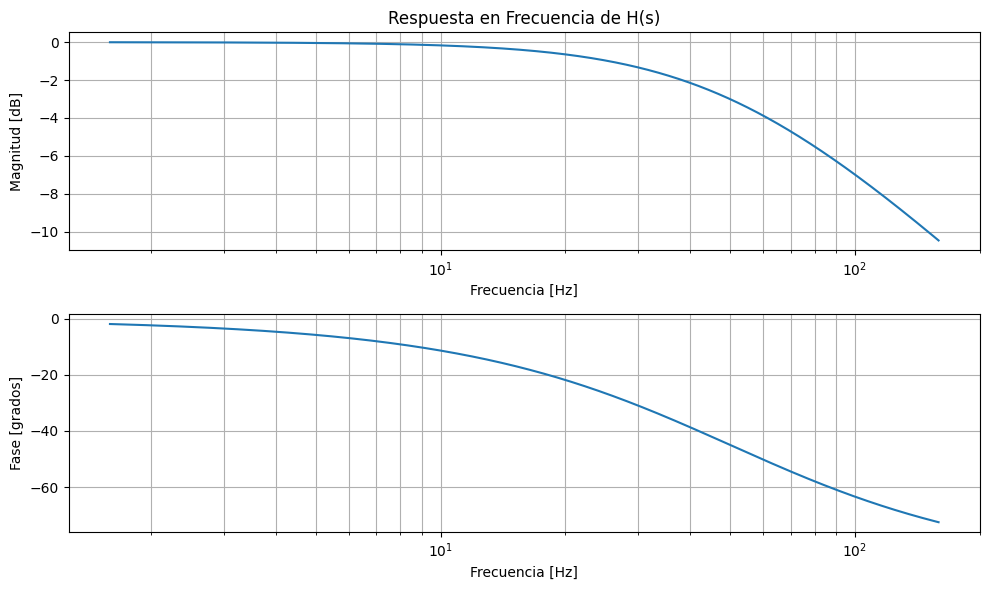

In [ ]:
w, H = signal.freqresp(h_s)
mag = np.abs(H)
phase = np.angle(H)

plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.semilogx(w / (2 * np.pi), 20 * np.log10(mag))
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Magnitud [dB]')
plt.title('Respuesta en Frecuencia de H(s)')
plt.grid(True, which='both')

plt.subplot(2, 1, 2)
plt.semilogx(w / (2 * np.pi), np.degrees(phase))
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Fase [grados]')
plt.grid(True, which='both')

plt.tight_layout()
plt.show()

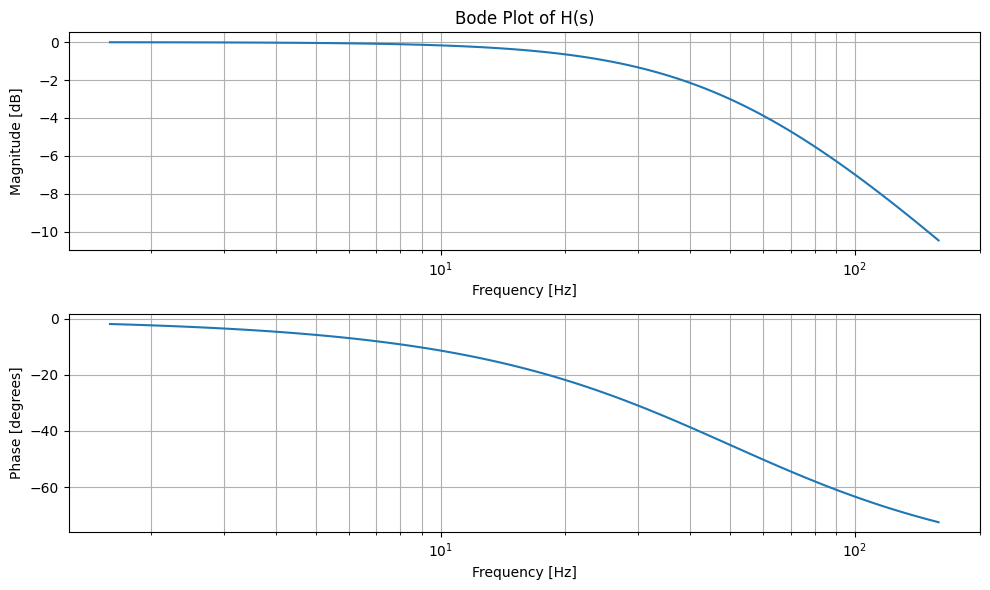

In [ ]:
w, mag, phase = signal.bode(h_s)

plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.semilogx(w / (2 * np.pi), mag)
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude [dB]')
plt.title('Bode Plot of H(s)')
plt.grid(True, which='both')

plt.subplot(2, 1, 2)
plt.semilogx(w / (2 * np.pi), phase)
plt.xlabel('Frequency [Hz]')
plt.ylabel('Phase [degrees]')
plt.grid(True, which='both')

plt.tight_layout()
plt.show()

In [ ]:
fs=1e3 # 1 khz
ts =1/fs

h_d = h_s.to_discrete(ts, method="bilinear")
h_d

TransferFunctionDiscrete(
array([0.13575525, 0.13575525]),
array([ 1.       , -0.7284895]),
dt: 0.001
)

In [ ]:
a=-h_d.den[1:]
b=h_d.num

b,a

(array([0.13575525, 0.13575525]), array([0.7284895]))

## Generación de la señal

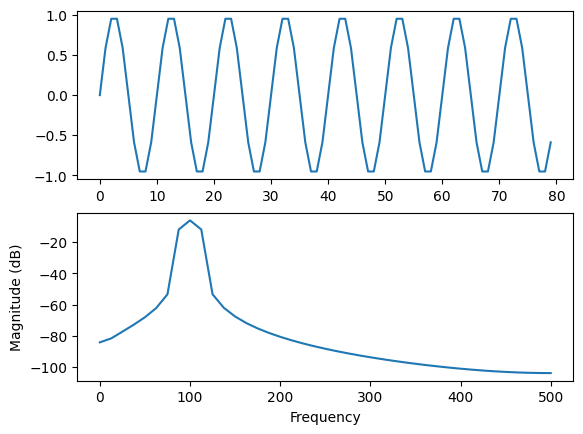

In [ ]:
f=100
t=1/f
ts = 1/fs

N = t/ts*8
n = np.arange(N)
t=n*ts
x = np.sin(2*np.pi*f*t)

plt.subplot(2,1,1)
plt.plot(x)

plt.subplot(2,1,2)
plt.magnitude_spectrum(x, Fs=fs, scale="dB")
plt.show()

## Filtrado

In [ ]:
y = signal.filtfilt(h_d.num, h_d.den, x=x)
#y

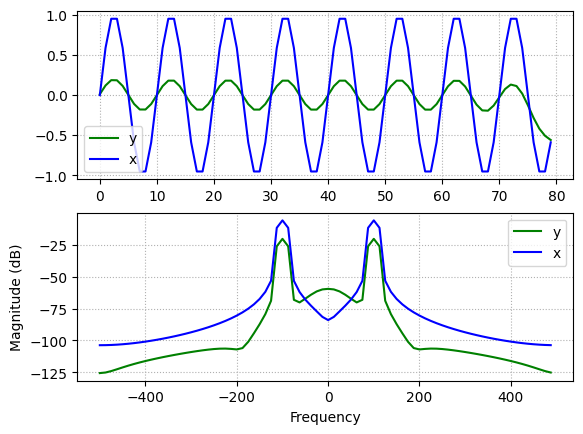

In [ ]:
plt.subplot(2,1,1)
plt.plot(y, label="y", c="green")
plt.plot(x, label="x", c="blue")
plt.grid(ls=":")
plt.legend()

plt.subplot(2,1,2)
plt.magnitude_spectrum(y, Fs=fs, scale="dB", c="green", label="y", sides='twosided')
plt.magnitude_spectrum(x, Fs=fs, scale="dB", c="blue", label="x",sides='twosided')
plt.grid(ls=":")
plt.legend()

plt.show()